 # Matrix Profile Deep Dive — HealthyGamerGG



 1. Multi-dimensional matrix profile (top PCA dims weighted by explained variance)

 2. Semantic labels at each discord window (TF-IDF on transcript text)

 3. Regime segmentation + era report

 4. Matrix profile on engagement signals + overlay with content MP

 5. Motif analysis — what content does the channel keep returning to?

In [23]:
# !pip install stumpy scipy -q


 ## Imports & Setup

In [24]:
import sys
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks

import stumpy

from sqlalchemy import text
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer

sys.path.insert(0, '.')
from models import engine

plt.rcParams['figure.dpi'] = 120


 ## Config

In [25]:
CHANNEL_QUERY    = 'healthygamergg'
CONTENT_TYPE     = 'long'
SHORTS_MAX_SECS  = 180

MP_WINDOW        = 25    # subsequence length (videos). Larger = smoother, misses short eras
PCA_DIMS         = 10    # how many PCA dims to include in multi-dim profile
N_DISCORDS       = 6     # how many regime breaks to find
MIN_DISCORD_SEP  = 30    # minimum videos between two discords
MOTIF_TOP_N      = 3     # how many motifs to show


 ## Load Data

In [26]:
_dur = {
    'long':  f'AND v.duration_seconds > {SHORTS_MAX_SECS}',
    'short': f'AND v.duration_seconds <= {SHORTS_MAX_SECS}',
    'all':   '',
}[CONTENT_TYPE]

# Video-level data with mean-pooled embeddings
_sql_videos = f"""
    SELECT
        v.video_id, v.title, v.published_at, v.duration_seconds,
        v.view_count, v.like_count, v.engagement_rate,
        v.transcript_words_per_minute, v.transcript_word_count,
        avg(tc.embedding) AS mean_embedding
    FROM videos v
    JOIN channels c ON v.channel_id = c.channel_id
    JOIN transcript_chunks tc ON v.video_id = tc.video_id
    WHERE LOWER(c.title) LIKE LOWER('%{CHANNEL_QUERY}%')
      AND tc.embedding IS NOT NULL
      {_dur}
    GROUP BY
        v.video_id, v.title, v.published_at, v.duration_seconds,
        v.view_count, v.like_count, v.engagement_rate,
        v.transcript_words_per_minute, v.transcript_word_count
    ORDER BY v.published_at
"""

# Transcript text per video (for semantic labeling of eras)
_sql_text = f"""
    SELECT v.video_id, string_agg(tc.text, ' ' ORDER BY tc.chunk_index) AS full_text
    FROM videos v
    JOIN channels c ON v.channel_id = c.channel_id
    JOIN transcript_chunks tc ON v.video_id = tc.video_id
    WHERE LOWER(c.title) LIKE LOWER('%{CHANNEL_QUERY}%')
      {_dur}
    GROUP BY v.video_id
"""

with engine.connect() as conn:
    result = conn.execute(text(_sql_videos))
    df = pd.DataFrame(result.fetchall(), columns=result.keys())

    result_text = conn.execute(text(_sql_text))
    df_text = pd.DataFrame(result_text.fetchall(), columns=result_text.keys())

df = df.merge(df_text, on='video_id', how='left')
df['published_at'] = pd.to_datetime(df['published_at'], utc=True)
df['month'] = df['published_at'].dt.to_period('M')


def _parse_emb(v):
    if isinstance(v, np.ndarray):
        return v.astype(float)
    if isinstance(v, (list, tuple)):
        return np.array(v, dtype=float)
    nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', str(v))
    return np.array(nums, dtype=float)


df['embedding'] = df['mean_embedding'].apply(_parse_emb)
emb      = np.stack(df['embedding'].values)
emb_norm = normalize(emb)

pca      = PCA(n_components=PCA_DIMS, random_state=42)
emb_pca  = pca.fit_transform(emb_norm)

print(f'Loaded {len(df)} videos  |  {df["published_at"].min().date()} -> {df["published_at"].max().date()}')
print(f'PCA explained variance ({PCA_DIMS} dims): {pca.explained_variance_ratio_.sum():.1%}')


Loaded 1021 videos  |  2019-01-25 -> 2026-03-22
PCA explained variance (10 dims): 45.0%


 ## 1. Multi-Dimensional Matrix Profile

 Run matrix profile on each PCA dimension independently,

 then combine with weights proportional to explained variance.

 Result: a single distance signal where peaks = most anomalous windows.

In [27]:
weights   = pca.explained_variance_ratio_[:PCA_DIMS]
weights   = weights / weights.sum()
n_profile = len(df) - MP_WINDOW + 1

mp_combined = np.zeros(n_profile)
mp_per_dim  = []

print('Computing matrix profiles...')
for dim in range(PCA_DIMS):
    signal = emb_pca[:, dim].astype(np.float64)
    mp_dim = stumpy.stump(signal, m=MP_WINDOW)[:, 0].astype(float)
    mp_per_dim.append(mp_dim)
    mp_combined += weights[dim] * mp_dim
    print(f'  dim {dim+1}/{PCA_DIMS}  (weight={weights[dim]:.3f})')

# Z-score normalise for display
mp_z = (mp_combined - mp_combined.mean()) / (mp_combined.std() + 1e-10)

# Timestamps aligned to window start
mp_dates = df['published_at'].values[:n_profile]

print('Done.')


Computing matrix profiles...
  dim 1/10  (weight=0.225)
  dim 2/10  (weight=0.158)
  dim 3/10  (weight=0.125)
  dim 4/10  (weight=0.099)
  dim 5/10  (weight=0.086)
  dim 6/10  (weight=0.074)
  dim 7/10  (weight=0.067)
  dim 8/10  (weight=0.058)
  dim 9/10  (weight=0.056)
  dim 10/10  (weight=0.053)
Done.


 ## 2. Discord Detection

 Discords = windows with the highest MP distance = regime breaks.

 We enforce a minimum separation so we get spread-out boundaries, not clusters.

Top 6 discords:
  #1  [2019-11-13]  z=2.71  — "Narcissistic Father, Childhood Trauma, and Life Goals | Dr.K Interviews"
  #2  [2019-12-20]  z=2.33  — "Why People Say Meditation Can Change Your Life | Dharana and Focus Explained"
  #3  [2021-06-08]  z=2.40  — "Psychiatrist Clarifies Important Point About Therapy"
  #4  [2022-03-02]  z=1.99  — "Psychiatrist Reacts to ADHD TikToks"
  #5  [2023-05-16]  z=2.82  — "How Years Of Gaming Affects Your Brain"
  #6  [2023-12-08]  z=1.98  — "How To Have An Easy Life"


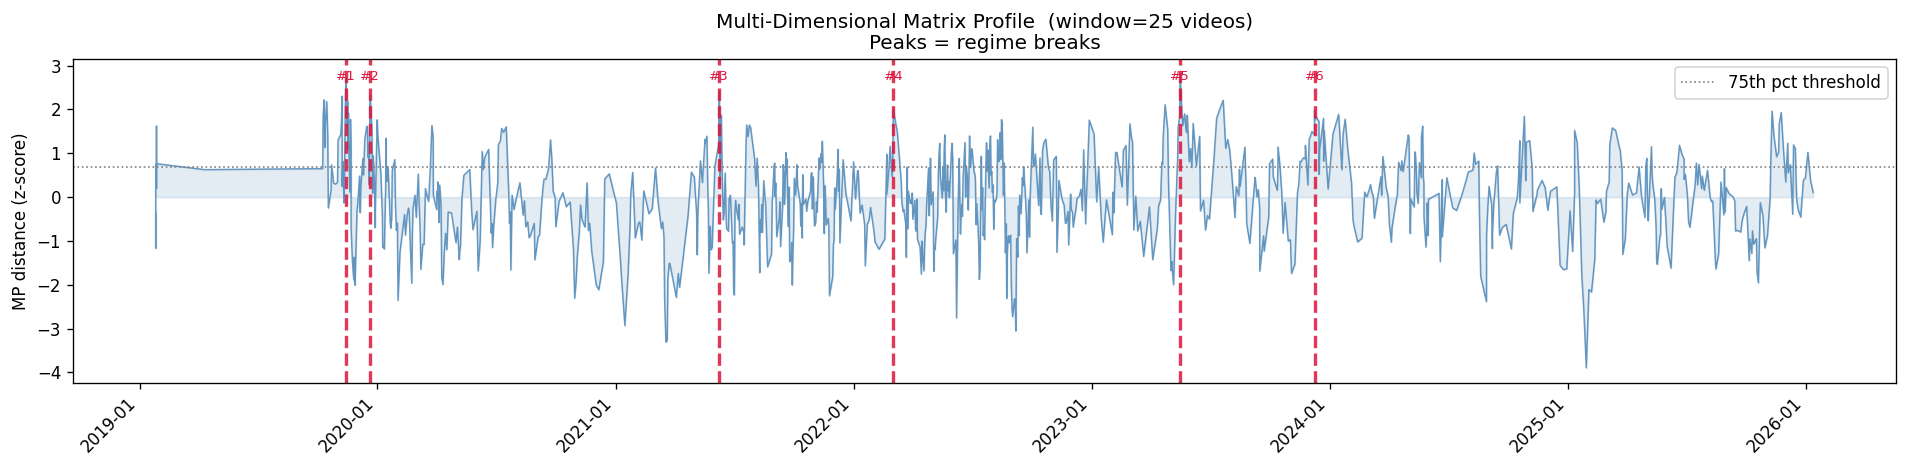

In [28]:
# Find peaks in combined MP signal
peaks, props = find_peaks(
    mp_z,
    height=np.percentile(mp_z, 75),   # only consider top 25%
    distance=MIN_DISCORD_SEP,
    prominence=0.5,
)

# Take top N by height
top_peaks = peaks[np.argsort(props['peak_heights'])[::-1][:N_DISCORDS]]
top_peaks  = np.sort(top_peaks)   # back to chronological order

print(f'Top {len(top_peaks)} discords:')
for rank, idx in enumerate(top_peaks, 1):
    vid_idx = min(idx + MP_WINDOW // 2, len(df) - 1)   # centre of window
    print(f'  #{rank}  [{df["published_at"].iloc[idx].date()}]  z={mp_z[idx]:.2f}  '
          f'— "{df["title"].iloc[vid_idx]}"')

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(mp_dates, mp_z, lw=0.9, color='steelblue', alpha=0.8)
ax.fill_between(mp_dates, mp_z, alpha=0.15, color='steelblue')
ax.axhline(np.percentile(mp_z, 75), color='grey', ls=':', lw=1, label='75th pct threshold')
for rank, idx in enumerate(top_peaks, 1):
    ax.axvline(mp_dates[idx], color='crimson', lw=2, ls='--', alpha=0.85)
    ax.text(mp_dates[idx], mp_z.max() * 0.95, f'#{rank}',
            color='crimson', fontsize=8, ha='center')
ax.set_title(f'Multi-Dimensional Matrix Profile  (window={MP_WINDOW} videos)\nPeaks = regime breaks')
ax.set_ylabel('MP distance (z-score)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('mp_discords.png', bbox_inches='tight')
plt.show()


 ## 3. Regime Segmentation + Era Report

 Use discord peaks as era boundaries.

 Label each era with TF-IDF on transcript text (falls back to titles).

7 eras defined.

=== ERA REPORT ===

          start         end  n_videos  median_views  mean_engagement    mean_wpm  mean_duration_m
era                                                                                              
1    2019-01-25  2019-11-23        52      113867.5         0.039350         NaN        21.803205
2    2019-11-25  2020-01-08        31      143503.0         0.032642         NaN        45.326882
3    2020-01-09  2021-06-22       205      239960.0         0.035728  180.500000        83.959106
4    2021-06-23  2022-03-25       146      207752.0         0.042993         NaN        42.475000
5    2022-03-28  2023-06-10       254      200051.5         0.041851  221.600000        41.135499
6    2023-06-15  2024-01-05        71      435532.0         0.043249         NaN        54.887324
7    2024-01-14  2026-03-22       262      284915.0         0.038236  184.666667        71.004580

=== MOST REPRESENTATIVE VIDEOS PER ERA ===

Era 1  (2019-01-25 -> 2019-11-23)
  

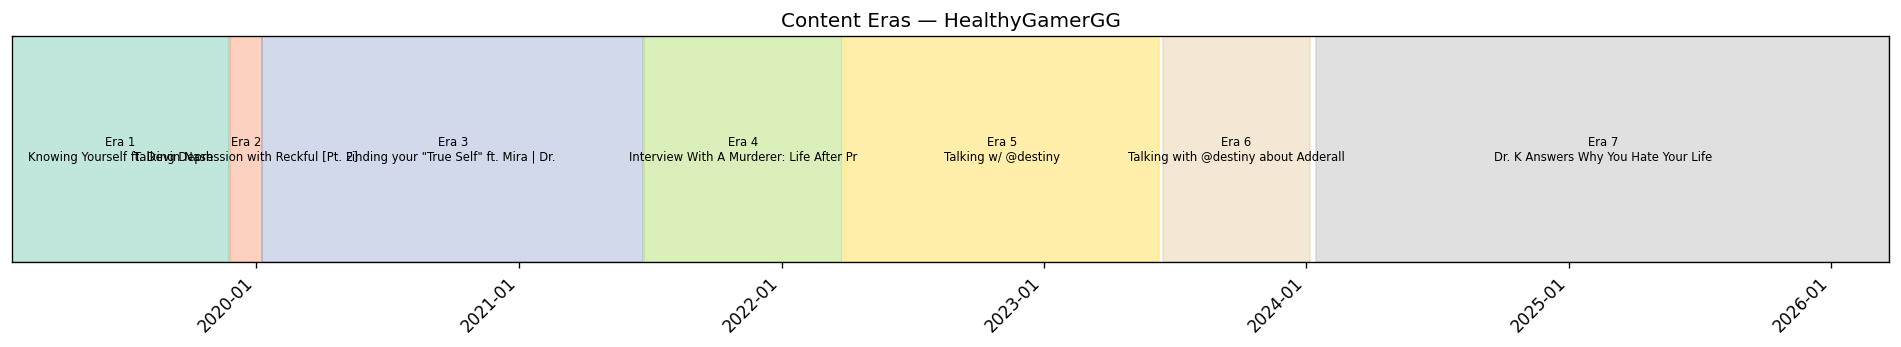

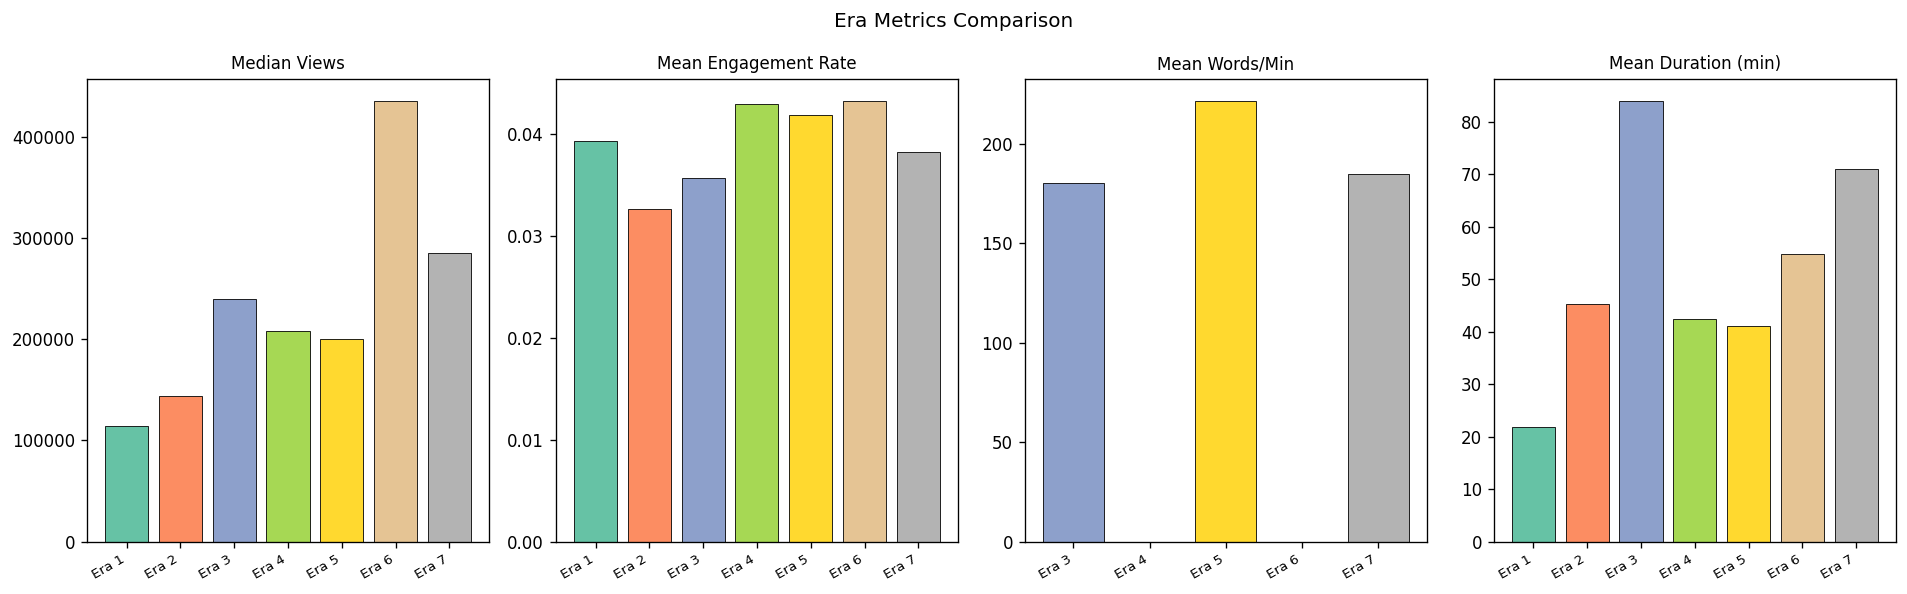

In [29]:
# Build era boundaries from discord indices
# Boundary = the video at the centre of each discord window
boundary_video_indices = sorted([min(idx + MP_WINDOW // 2, len(df) - 1) for idx in top_peaks])
era_slices = list(zip(
    [0] + boundary_video_indices,
    boundary_video_indices + [len(df)]
))

print(f'{len(era_slices)} eras defined.\n')


def tfidf_top_terms(texts, n=8):
    texts = [t for t in texts if isinstance(t, str) and len(t.strip()) > 10]
    if not texts:
        return []
    tfidf = TfidfVectorizer(max_features=500, stop_words='english',
                            ngram_range=(1, 2), min_df=1)
    try:
        mat   = tfidf.fit_transform(texts)
        terms = tfidf.get_feature_names_out()
        scores = mat.mean(axis=0).A1
        return [terms[i] for i in scores.argsort()[::-1][:n]]
    except Exception:
        return []


era_reports = []
df['era'] = -1

# --- Pass 1: assign era labels and collect per-era data ---
era_data = []
for era_num, (start, end) in enumerate(era_slices):
    df.iloc[start:end, df.columns.get_loc('era')] = era_num
    era_df       = df.iloc[start:end]
    era_emb_norm = normalize(np.stack(era_df['embedding'].values))

    # Find the ~20 videos closest to the era centroid
    centroid = era_emb_norm.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-10)
    sims     = era_emb_norm @ centroid
    top_idx  = sims.argsort()[::-1][:20]

    # Concatenate their text into one era-level document
    texts  = era_df.iloc[top_idx]['full_text'].tolist()
    texts  = [t for t in texts if isinstance(t, str) and len(t.strip()) > 10]
    titles = era_df.iloc[top_idx]['title'].tolist()

    era_data.append({
        'era_num':  era_num,
        'era_df':   era_df,
        'doc':      ' '.join(texts) if texts else ' '.join(titles),
    })

# --- Cross-era TF-IDF: each era is one document ---
# IDF will penalise terms common across all eras (think, know, just, etc.)
cross_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
)
era_docs  = [e['doc'] for e in era_data]
tfidf_mat = cross_tfidf.fit_transform(era_docs)
terms_arr = cross_tfidf.get_feature_names_out()

for era_num, e in enumerate(era_data):
    # Label by the titles of the videos closest to the era centroid
    # More interpretable than TF-IDF on a channel with consistent vocabulary
    era_df_e     = e['era_df']
    era_emb_norm = normalize(np.stack(era_df_e['embedding'].values))
    centroid     = era_emb_norm.mean(axis=0)
    centroid     = centroid / (np.linalg.norm(centroid) + 1e-10)
    sims         = era_emb_norm @ centroid
    top_idx      = sims.argsort()[::-1][:3]
    e['top_terms']   = era_df_e.iloc[top_idx]['title'].tolist()
    e['top_terms_str'] = ' | '.join(t[:40] for t in e['top_terms'])

for e in era_data:
    era_df = e['era_df']
    report = {
        'era':             e['era_num'] + 1,
        'start':           era_df['published_at'].iloc[0].date(),
        'end':             era_df['published_at'].iloc[-1].date(),
        'n_videos':        len(era_df),
        'median_views':    era_df['view_count'].median(),
        'mean_engagement': era_df['engagement_rate'].mean(),
        'mean_wpm':        era_df['transcript_words_per_minute'].mean(),
        'mean_duration_m': era_df['duration_seconds'].mean() / 60,
        'top_terms':       e['top_terms_str'],
    }
    era_reports.append(report)

era_df_report = pd.DataFrame(era_reports).set_index('era')
print('=== ERA REPORT ===\n')
print(era_df_report[['start', 'end', 'n_videos', 'median_views',
                       'mean_engagement', 'mean_wpm', 'mean_duration_m']].to_string())
print('\n=== MOST REPRESENTATIVE VIDEOS PER ERA ===\n')
for e in era_data:
    era_df_e = e['era_df']
    print(f"Era {e['era_num']+1}  ({era_df_e['published_at'].iloc[0].date()} -> {era_df_e['published_at'].iloc[-1].date()})")
    for title in e['top_terms']:
        print(f"  - {title}")
    print()

print('\n=== VIDEOS AROUND EACH ERA BREAK ===\n')
BREAK_CONTEXT = 5  # videos either side to show
for rank, bkp_vid_idx in enumerate(boundary_video_indices, 1):
    print(f'--- Break #{rank}  (boundary ~video index {bkp_vid_idx}, '
          f'{df["published_at"].iloc[bkp_vid_idx].date()}) ---')
    lo = max(0, bkp_vid_idx - BREAK_CONTEXT)
    hi = min(len(df), bkp_vid_idx + BREAK_CONTEXT + 1)
    context = df.iloc[lo:hi][['published_at', 'title', 'view_count']].copy()
    context['published_at'] = context['published_at'].dt.date
    context['marker'] = ''
    context.loc[df.index[bkp_vid_idx], 'marker'] = '<-- break'
    print(context.to_string(index=False))
    print()

# Visual era timeline
palette = plt.cm.Set2(np.linspace(0, 1, len(era_slices)))

fig, ax = plt.subplots(figsize=(16, 3))
for era_num, (start, end) in enumerate(era_slices):
    era_videos = df.iloc[start:end]
    t0 = era_videos['published_at'].iloc[0]
    t1 = era_videos['published_at'].iloc[-1]
    ax.axvspan(t0, t1, alpha=0.4, color=palette[era_num])
    mid = t0 + (t1 - t0) / 2
    terms_short = era_data[era_num]['top_terms'][0][:40]
    ax.text(mid, 0.5, f"Era {era_num+1}\n{terms_short}",
            ha='center', va='center', fontsize=7)

ax.set_xlim(df['published_at'].min(), df['published_at'].max())
ax.set_yticks([])
ax.set_title('Content Eras — HealthyGamerGG')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('mp_era_timeline.png', bbox_inches='tight')
plt.show()

# Era metrics comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics  = ['median_views', 'mean_engagement', 'mean_wpm', 'mean_duration_m']
mlabels  = ['Median Views', 'Mean Engagement Rate', 'Mean Words/Min', 'Mean Duration (min)']
era_nums = era_df_report.index.tolist()

for ax, metric, mlabel in zip(axes, metrics, mlabels):
    vals   = era_df_report[metric].values
    colors = [palette[i] for i in range(len(vals))]
    ax.bar([f'Era {e}' for e in era_nums], vals, color=colors, edgecolor='k', linewidth=0.5)
    ax.set_title(mlabel, fontsize=10)
    ax.set_xlabel('')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Era Metrics Comparison', fontsize=12)
plt.tight_layout()
plt.savefig('mp_era_metrics.png', bbox_inches='tight')
plt.show()


 ## 4. Engagement Signal Matrix Profile

 Run matrix profile independently on view count, engagement rate, and WPM.

 Overlay peaks with the content MP to find eras where BOTH content AND audience response shifted.

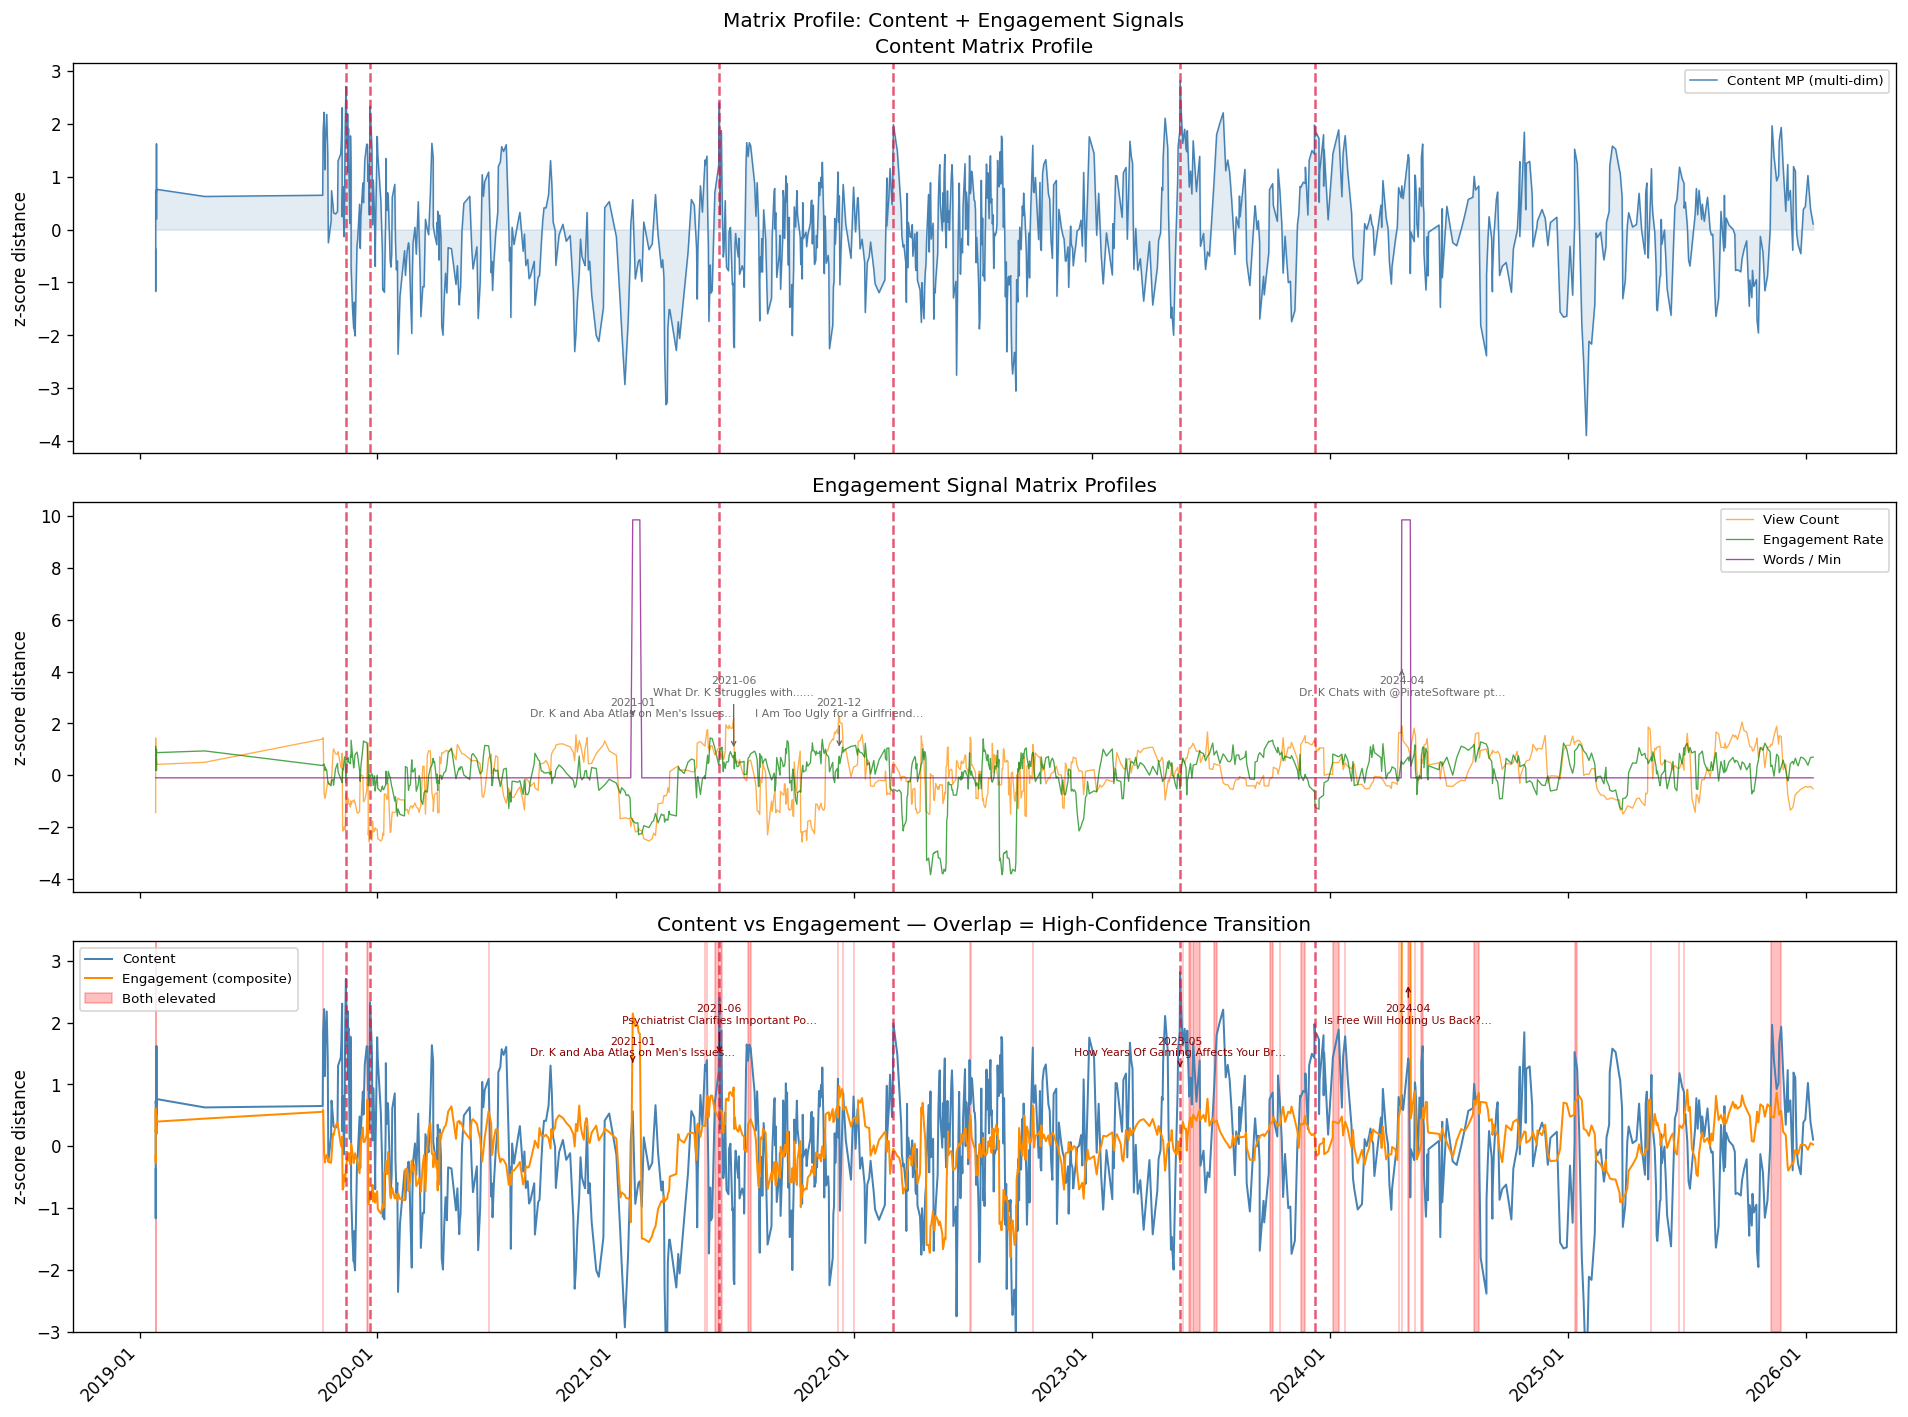

In [30]:
def engagement_mp(series, window):
    """Z-score normalise, fill NaN with median, compute matrix profile."""
    s = series.fillna(series.median()).values.astype(np.float64)
    s = (s - s.mean()) / (s.std() + 1e-10)
    mp = stumpy.stump(s, m=window)[:, 0].astype(float)
    return (mp - mp.mean()) / (mp.std() + 1e-10)


engagement_signals = {
    'View Count':         df['view_count'],
    'Engagement Rate':    df['engagement_rate'],
    'Words / Min':        df['transcript_words_per_minute'],
}

eng_mps = {name: engagement_mp(sig, MP_WINDOW) for name, sig in engagement_signals.items()}

# Composite engagement MP (mean of all three)
eng_mp_combined = np.mean(list(eng_mps.values()), axis=0)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# --- Content MP ---
ax = axes[0]
ax.plot(mp_dates, mp_z, lw=0.9, color='steelblue', label='Content MP (multi-dim)')
ax.fill_between(mp_dates, mp_z, alpha=0.15, color='steelblue')
for idx in top_peaks:
    ax.axvline(mp_dates[idx], color='crimson', lw=1.5, ls='--', alpha=0.7)
ax.set_title('Content Matrix Profile')
ax.set_ylabel('z-score distance')
ax.legend(fontsize=8)

def annotate_peaks(ax, signal, dates, df, n=4, color='black', min_sep=MIN_DISCORD_SEP):
    """Label the top N peaks with date + truncated video title."""
    peaks_idx, _ = find_peaks(signal, distance=min_sep, prominence=0.3)
    if len(peaks_idx) == 0:
        return
    # Sort by signal height at peak position
    top = peaks_idx[np.argsort(signal[peaks_idx])[::-1][:n]]
    y_max = signal.max()
    for i, idx in enumerate(sorted(top)):
        vid_idx = min(idx + MP_WINDOW // 2, len(df) - 1)
        title   = df['title'].iloc[vid_idx][:35] + '…'
        date    = pd.Timestamp(dates[idx]).strftime('%Y-%m')
        offset  = (0.55 + (i % 2) * 0.2) * y_max   # alternate heights to avoid overlap
        ax.annotate(
            f'{date}\n{title}',
            xy=(dates[idx], signal[idx]),
            xytext=(dates[idx], offset),
            fontsize=6.5, color=color, ha='center',
            arrowprops=dict(arrowstyle='->', color=color, lw=0.8),
        )


# --- Individual engagement MPs ---
ax = axes[1]
eng_colors = ['darkorange', 'green', 'purple']
for (name, mp_sig), color in zip(eng_mps.items(), eng_colors):
    ax.plot(mp_dates, mp_sig[:len(mp_dates)], lw=0.8, alpha=0.7, color=color, label=name)
for idx in top_peaks:
    ax.axvline(mp_dates[idx], color='crimson', lw=1.5, ls='--', alpha=0.7)
# Label top peaks for the composite engagement signal
annotate_peaks(ax, eng_mp_combined[:len(mp_dates)], mp_dates, df, n=4, color='dimgray')
ax.set_title('Engagement Signal Matrix Profiles')
ax.set_ylabel('z-score distance')
ax.legend(fontsize=8)

# --- Overlay: content vs composite engagement ---
ax = axes[2]
ax.plot(mp_dates, mp_z, lw=1.2, color='steelblue', label='Content')
ax.plot(mp_dates, eng_mp_combined[:len(mp_dates)], lw=1.2, color='darkorange', label='Engagement (composite)')
# Highlight windows where BOTH are high — true regime transitions
both_high = (mp_z > np.percentile(mp_z, 75)) & (eng_mp_combined[:len(mp_dates)] > np.percentile(eng_mp_combined, 75))
ax.fill_between(mp_dates, -3, 5, where=both_high, alpha=0.25, color='red', label='Both elevated')
for idx in top_peaks:
    ax.axvline(mp_dates[idx], color='crimson', lw=1.5, ls='--', alpha=0.7)
# Label peaks where engagement and content both spike
both_signal = (mp_z + eng_mp_combined[:len(mp_dates)]) / 2
annotate_peaks(ax, both_signal, mp_dates, df, n=4, color='darkred')
ax.set_title('Content vs Engagement — Overlap = High-Confidence Transition')
ax.set_ylabel('z-score distance')
ax.set_ylim(-3, mp_z.max() + 0.5)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Matrix Profile: Content + Engagement Signals', fontsize=12)
plt.tight_layout()
plt.savefig('mp_engagement_overlay.png', bbox_inches='tight')
plt.show()


 ## 5. Motif Analysis

 Motifs = windows with the LOWEST matrix profile distance = most self-similar content.

 These are the channel's "home base" — topics it naturally gravitates back to.

=== Top 3 Motifs (most recurring content patterns) ===

Motif #1  [2025-01-28 — 2025-04-23]
  MP distance : 4.0337  (lower = more self-similar)
  Top terms   : like, right, people, know, going
  Sample titles:
    - i was addicted to "self help". here's the truth.
    - Avoidant Personality Disorder Deep Dive w/ Dr. Honda, @PsychologyInSeattle
    - Why Women Can't Find A Soulmate
    - Why Introverts Struggle With Charisma

Motif #2  [2021-03-18 — 2021-05-25]
  MP distance : 4.0904  (lower = more self-similar)
  Top terms   : like, know, think, yeah, just
  Sample titles:
    - Why You're Impulsive ft. Rich Campbell
    - Psychiatrist reacts to: "I have too much self-awareness"
    - Why You Repeatedly Give Up
    - Psychiatrist's thoughts on Nice Guys

Motif #3  [2022-09-06 — 2022-10-06]
  MP distance : 4.1151  (lower = more self-similar)
  Top terms   : like, people, know, don, just
  Sample titles:
    - Quiet Quitting? Should You Do It?
    - I’m Afraid to Move Forward, What Do I 

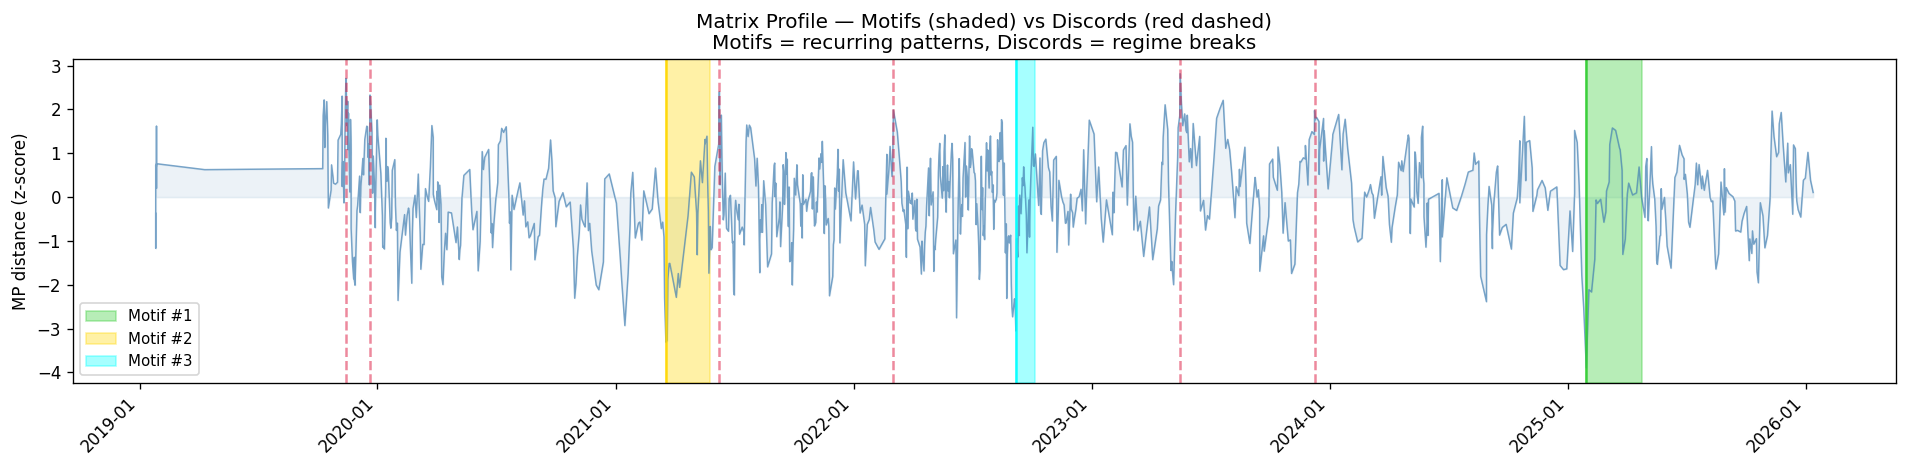

In [31]:
# Find top N motifs (each well-separated from previous ones)
sorted_asc = np.argsort(mp_combined)
motifs = []
for idx in sorted_asc:
    if all(abs(idx - m) >= MIN_DISCORD_SEP for m in motifs):
        motifs.append(int(idx))
    if len(motifs) >= MOTIF_TOP_N:
        break

print(f'=== Top {MOTIF_TOP_N} Motifs (most recurring content patterns) ===\n')
for rank, idx in enumerate(motifs, 1):
    window_vids = df.iloc[idx:idx + MP_WINDOW]
    top_terms   = tfidf_top_terms(window_vids['full_text'].tolist(), n=5) or \
                  tfidf_top_terms(window_vids['title'].tolist(), n=5)
    print(f'Motif #{rank}  [{df["published_at"].iloc[idx].date()} — '
          f'{df["published_at"].iloc[min(idx + MP_WINDOW - 1, len(df)-1)].date()}]')
    print(f'  MP distance : {mp_combined[idx]:.4f}  (lower = more self-similar)')
    print(f'  Top terms   : {", ".join(top_terms)}')
    print(f'  Sample titles:')
    for title in window_vids['title'].head(4).tolist():
        print(f'    - {title}')
    print()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(mp_dates, mp_z, lw=0.9, color='steelblue', alpha=0.7)
ax.fill_between(mp_dates, mp_z, alpha=0.1, color='steelblue')

motif_colors = ['limegreen', 'gold', 'cyan']
for rank, (idx, color) in enumerate(zip(motifs, motif_colors), 1):
    ax.axvspan(mp_dates[idx],
               mp_dates[min(idx + MP_WINDOW - 1, n_profile - 1)],
               alpha=0.35, color=color, label=f'Motif #{rank}')
    ax.axvline(mp_dates[idx], color=color, lw=1.5, alpha=0.9)

# Discord peaks for reference
for idx in top_peaks:
    ax.axvline(mp_dates[idx], color='crimson', lw=1.5, ls='--', alpha=0.5)

ax.set_title('Matrix Profile — Motifs (shaded) vs Discords (red dashed)\nMotifs = recurring patterns, Discords = regime breaks')
ax.set_ylabel('MP distance (z-score)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('mp_motifs.png', bbox_inches='tight')
plt.show()


 ## Summary: All Signals Together

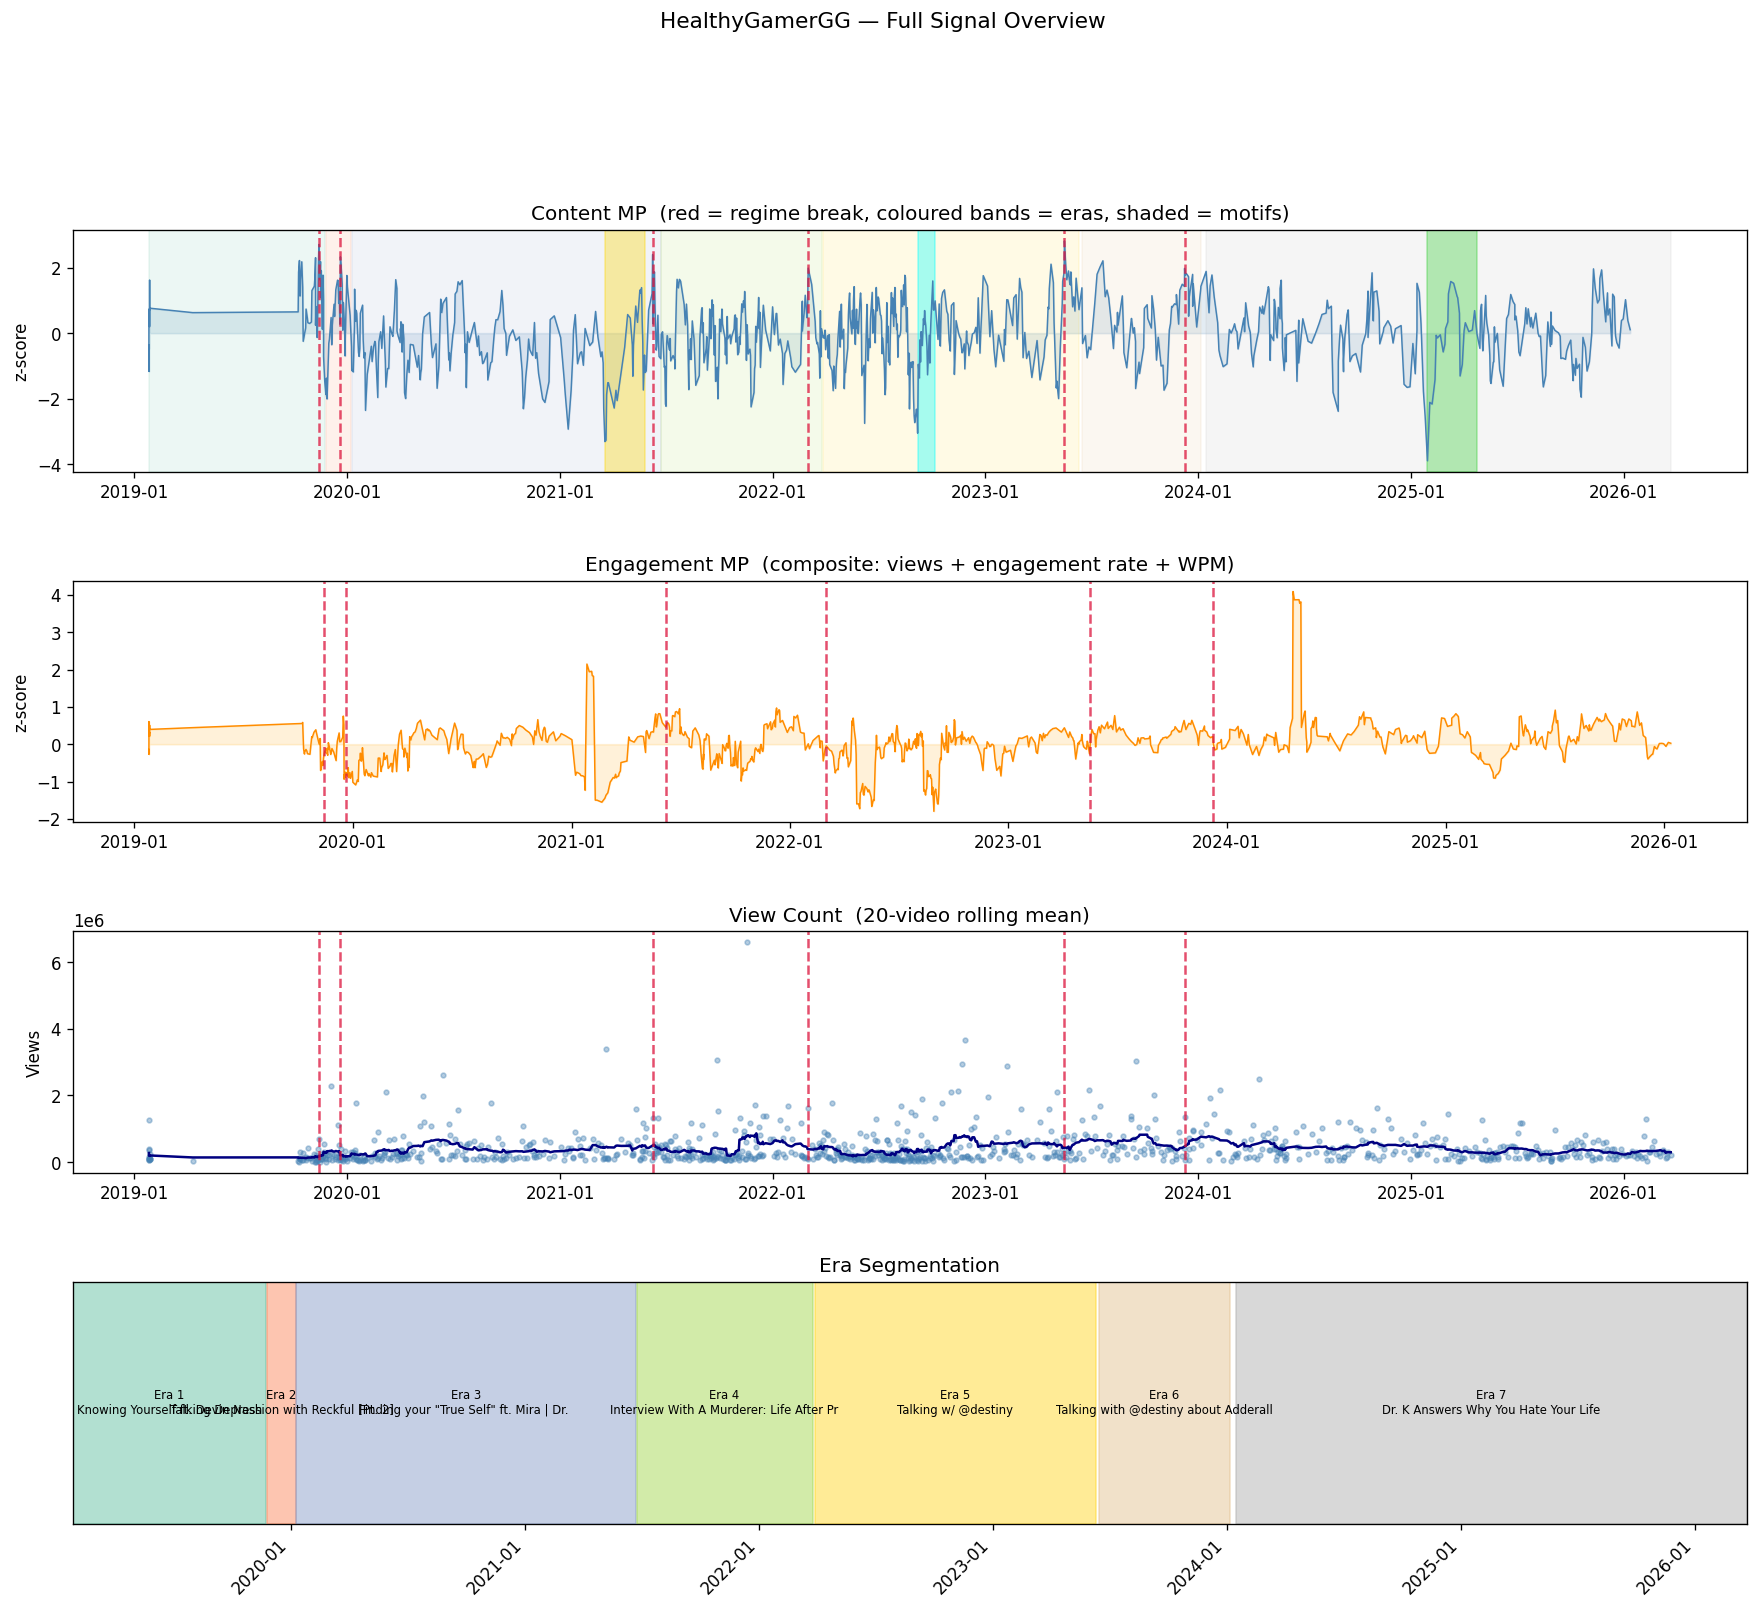

In [32]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

dates_full = df['published_at'].values

# --- 1. Content MP with eras ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(mp_dates, mp_z, lw=0.9, color='steelblue')
ax1.fill_between(mp_dates, mp_z, alpha=0.15, color='steelblue')
for era_num, (start, end) in enumerate(era_slices):
    t0 = df['published_at'].iloc[start]
    t1 = df['published_at'].iloc[end - 1]
    ax1.axvspan(t0, t1, alpha=0.12, color=palette[era_num])
for idx in top_peaks:
    ax1.axvline(mp_dates[idx], color='crimson', lw=1.5, ls='--', alpha=0.75)
for rank, (idx, color) in enumerate(zip(motifs, motif_colors), 1):
    ax1.axvspan(mp_dates[idx], mp_dates[min(idx + MP_WINDOW - 1, n_profile - 1)],
                alpha=0.35, color=color)
ax1.set_title('Content MP  (red = regime break, coloured bands = eras, shaded = motifs)')
ax1.set_ylabel('z-score')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- 2. Engagement composite MP ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(mp_dates, eng_mp_combined[:len(mp_dates)], lw=0.9, color='darkorange')
ax2.fill_between(mp_dates, eng_mp_combined[:len(mp_dates)], alpha=0.15, color='orange')
for idx in top_peaks:
    ax2.axvline(mp_dates[idx], color='crimson', lw=1.5, ls='--', alpha=0.75)
ax2.set_title('Engagement MP  (composite: views + engagement rate + WPM)')
ax2.set_ylabel('z-score')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- 3. View count raw ---
ax3 = fig.add_subplot(gs[2])
ax3.scatter(dates_full, df['view_count'], s=8, alpha=0.4, color='steelblue')
smooth_views = pd.Series(df['view_count'].values).rolling(20, center=True, min_periods=1).mean()
ax3.plot(dates_full, smooth_views, color='navy', lw=1.5)
for idx in top_peaks:
    ax3.axvline(mp_dates[idx], color='crimson', lw=1.5, ls='--', alpha=0.75)
ax3.set_title('View Count  (20-video rolling mean)')
ax3.set_ylabel('Views')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- 4. Era band ---
ax4 = fig.add_subplot(gs[3])
for era_num, (start, end) in enumerate(era_slices):
    era_videos = df.iloc[start:end]
    t0 = era_videos['published_at'].iloc[0]
    t1 = era_videos['published_at'].iloc[-1]
    ax4.axvspan(t0, t1, alpha=0.5, color=palette[era_num])
    mid = t0 + (t1 - t0) / 2
    terms_short = era_data[era_num]['top_terms'][0][:40]
    ax4.text(mid, 0.5, f"Era {era_num+1}\n{terms_short}",
             ha='center', va='center', fontsize=7)
ax4.set_xlim(df['published_at'].min(), df['published_at'].max())
ax4.set_yticks([])
ax4.set_title('Era Segmentation')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('HealthyGamerGG — Full Signal Overview', fontsize=13, y=1.01)
plt.savefig('mp_summary.png', bbox_inches='tight')
plt.show()
